Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs
from traditional machine learning.  

Answer:
Deep Learning is a specialized subfield of machine learning that utilizes multi-layered artificial neural networks to model and solve complex patterns in data. It evolved from early concepts like the 1950s Perceptron, through the development of backpropagation in the 1980s, to the current era, enabled by high-performance GPUs and massive datasets. The primary difference from traditional machine learning is that deep learning automatically performs feature extraction from raw data, whereas traditional machine learning often requires manual feature engineering by domain experts.

Question 2: Explain the basic architecture and functioning of a Perceptron. What are its
limitations?  

Answer:
A Perceptron is the simplest form of a neural network. Its architecture consists of:  
Input Values (x): Raw data points.  
Weights (w): Coefficients representing the strength of each input.  
Bias (b): An additional parameter to shift the activation function.  
Summation Function: Calculates the weighted sum (Z=∑wi​xi​+b).  
Activation Function: Usually a step function that produces a binary output (0 or 1) based on a threshold.  

Functioning: The model multiplies inputs by weights, adds the bias, and if the sum exceeds zero, it outputs a 1, otherwise it outputs a 0.  
Limitations: The Perceptron can only solve linearly separable problems. It is incapable of solving non-linear problems, such as the XOR gate logic.

Question 3: Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.  

Answer:
The purpose of an activation function is to introduce non-linearity into the network. Without it, a neural network regardless of how many layers it has would behave like a simple linear regression model.

Sigmoid	(0, 1)	Used for binary classification; prone to vanishing gradient problems.  
Tanh	(-1, 1)	Zero-centered, making optimization easier than Sigmoid, but still suffers from vanishing gradients.  
ReLU	[0, ∞)	Most popular; solves vanishing gradient issues and is computationally efficient, though it can lead to "dying neurons" if inputs are negative.

Question 4: What is the difference between Loss function and Cost function in neural
networks? Provide examples.  

Answer:
Loss Function: Measures the error of the model on a single training example.  
Example: Binary Cross-Entropy used for one specific transaction in fraud detection.  
Cost Function: Represents the average of all loss function values across the entire training dataset.  
Example: Mean Squared Error (MSE) calculated over all samples in a regression task.  

Question 5: What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.  

Answer:
The role of an optimizer is to update the weights and biases of the network to minimize the cost function.  
Gradient Descent: Updates parameters in the opposite direction of the gradient. It can be slow and often gets stuck in local minima.  
RMSprop: Uses a moving average of squared gradients to normalize the gradient, allowing for an adaptive learning rate that speeds up convergence.   
Adam: Combines the benefits of RMSprop and Momentum; it is widely considered the best general-purpose optimizer due to its efficiency and low memory requirements.

Question 6: Write a Python program to implement a single-layer perceptron from
scratch using NumPy to solve the logical AND gate.  

In [1]:
import numpy as np

def step_function(x):
    return 1 if x >= 0 else 0

def perceptron_and_gate():
    inputs = np.array([[0,0], [0,1], [1,0], [1,1]])
    targets = np.array([0, 0, 0, 1])
    
    weights = np.zeros(2)
    bias = 0
    lr = 0.1
    epochs = 10

    for _ in range(epochs):
        for i in range(len(inputs)):
            linear_output = np.dot(inputs[i], weights) + bias
            prediction = step_function(linear_output)
            
            error = targets[i] - prediction
            weights += lr * error * inputs[i]
            bias += lr * error

    return weights, bias

w, b = perceptron_and_gate()
print(f"Final Weights: {w}, Bias: {b}")

Final Weights: [0.2 0.1], Bias: -0.20000000000000004


Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions
using Matplotlib.

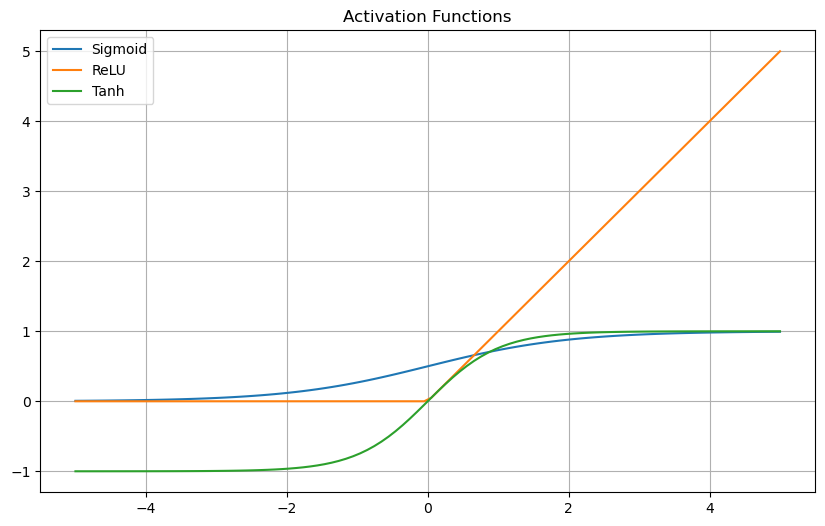

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, relu, label='ReLU')
plt.plot(x, tanh, label='Tanh')
plt.title("Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

Question 8: Use Keras to build and train a simple multilayer neural network on the
MNIST digits dataset. Print the training accuracy.

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
f_mnist=tf.keras.datasets.mnist
(x_train,y_train), (x_test,y_test) = f_mnist.load_data()
x_train=x_train/255
x_test=x_test/255

model=Sequential([
  Flatten(input_shape=(28,28,1)),
  Dense(64, activation='relu'),
  Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy' ,metrics=['accuracy'] )
model.fit(x_train,y_train, epochs=5, batch_size=64, validation_split=0.1)

c:\Users\Tatha\anaconda3\envs\pwskills\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8960 - loss: 0.3770 - val_accuracy: 0.9508 - val_loss: 0.1781
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9465 - loss: 0.1859 - val_accuracy: 0.9612 - val_loss: 0.1349
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9598 - loss: 0.1395 - val_accuracy: 0.9677 - val_loss: 0.1175
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9666 - loss: 0.1124 - val_accuracy: 0.9698 - val_loss: 0.1084
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9723 - loss: 0.0943 - val_accuracy: 0.9682 - val_loss: 0.1097


Question 9: Visualize the loss and accuracy curves for a neural network model trained
on the Fashion MNIST dataset. Interpret the training behavior.

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5592 - loss: 1.7410 - val_accuracy: 0.7747 - val_loss: 1.0859
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8031 - loss: 0.8656 - val_accuracy: 0.8695 - val_loss: 0.6271
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8544 - loss: 0.5991 - val_accuracy: 0.8952 - val_loss: 0.4632
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8751 - loss: 0.4869 - val_accuracy: 0.9073 - val_loss: 0.3846
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8863 - loss: 0.4273 - val_accuracy: 0.9133 - val_loss: 0.3411


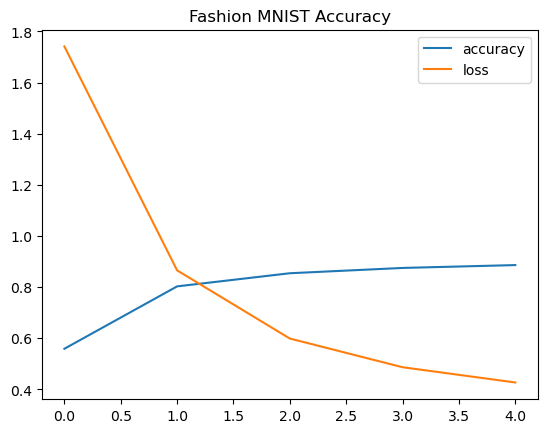

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

x_train=x_train/255
x_test=x_test/255

model=Sequential([
  Flatten(input_shape=(28,28,1)),
  Dense(64, activation='relu'),
  Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy' ,metrics=['accuracy'] )
history= model.fit(x_train,y_train, epochs=5, batch_size=64, validation_split=0.1)

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label='loss')
plt.title('Fashion MNIST Accuracy')
plt.legend()
plt.show()

Question 10: You are working on a project for a bank that wants to automatically detect
fraudulent transactions. The dataset is large, imbalanced, and contains structured
features like transaction amount, merchant ID, and customer location. The goal is to
classify each transaction as fraudulent or legitimate.  
Explain your real-time data science workflow:  
● How would you design a deep learning model (perceptron or multilayer NN)?  
● Which activation function and loss function would you use, and why?  
● How would you train and evaluate the model, considering class imbalance?  
● Which optimizer would be suitable, and how would you prevent overfitting?  

Answer:  
1. I would design a Multilayer Neural Network (MLNN). 
Structure: It would consist of an input layer (matching the number of structured features), multiple hidden layers to capture deep patterns, and a single-neuron output layer for classification.  
2. Hidden Layers (ReLU): I would use the ReLU (Rectified Linear Unit) activation function for hidden layers. It is computationally efficient and helps prevent the vanishing gradient problem, which is vital when dealing with the large datasets mentioned in the prompt.  
Output Layer (Sigmoid): Since we are classifying transactions as either fraudulent (1) or legitimate (0), a Sigmoid function is used at the output. It squashes the output value between 0 and 1, representing the probability of fraud.  
Loss Function (Binary Cross-Entropy): This is the standard loss function for binary classification. It penalizes the model heavily when it is confident about a wrong prediction, ensuring the network learns the distinction between the two classes effectively.  
3. Handling Imbalance During Training:  
Synthetic Minority Over-sampling Technique (SMOTE): Artificially creating new fraud samples to balance the dataset.   
Class Weights: Assigning a higher penalty (weight) to the "fraud" class in the loss function so the model prioritizes learning those rare cases.  
Evaluation Metrics: Standard "Accuracy" is misleading here because a model could achieve 99% accuracy just by predicting "not fraud" every time.  I would use:  
Precision-Recall Curves: To understand the trade-off between catching all fraud (Recall) and ensuring legitimate transactions aren't blocked (Precision).   
F1-Score: The harmonic mean of Precision and Recall.   
AUPRC (Area Under the Precision-Recall Curve): A better indicator of performance than ROC-AUC for imbalanced data.  
4. I would use the Adam optimizer. It is well-suited for large datasets and structured features because it adapts the learning rate for each parameter, handling noisy or sparse gradients effectively.  
Preventing Overfitting:  
Dropout: Randomly deactivating a percentage of neurons during training to prevent the model from becoming over-reliant on specific features.   
Early Stopping: Monitoring the validation loss and stopping the training process as soon as the model stops improving, preventing it from "memorizing" the training set.   
L2 Regularization: Adding a penalty to the loss function based on the size of the weights to keep the model simple.  